In [5]:
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from tqdm import tqdm
import multiprocessing as mp
from scipy.interpolate import interp1d
from matplotlib.ticker import AutoMinorLocator
from NSC_cosmo import background, PertEMD_noAX
from QCD_axions import NSC_PERT_axi
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter
from scipy.optimize import root_scalar
from scipy.interpolate import interp1d
import numpy as np
import matplotlib.pyplot as plt


plt.rcParams.update({
    "pdf.fonttype": 42,  
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath, amssymb}",
    
    "font.family": "serif",
    "font.size": 16,
    
    "axes.labelsize": 20,
    "axes.titlesize": 18,
    "legend.fontsize": 14,
    
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
})


labR = r'$R/R_I$'
labx  = r'$x$'
labka = r'$\kappa$'
labrh= r'$\rho_i$~[GeV$^4$]'
labT = r'$T$~[GeV]'
labdr= r'$|\delta_r(\kappa,x)|$'
labdp= r'$|\delta_\phi(\kappa,x)|$'
labtr= r'$|\theta_r(\kappa,x)|/k_\text{RH}$'
labtp= r'$|\theta_\phi(\kappa,x)|/k_\text{RH}$'
labPh= r'$|\Phi(\kappa,x)|$'

labdr2= labdr
labdp2= labdp
labtr2= labtr
labtp2= labtp
labPh2= labPh

labma= r'$m_a$~[GeV]'
labth= r'$\theta_0$'
Phi_p = np.sqrt(2.101* 10**(-9))  



In [6]:

Tend = 1.00929806e-01
Ma0 =2.41358776e-16
Tini = 3e1
kappa = 1e5
maxi = 70

R, rho_phi, rho_r, Temp, Hub, GG, R_RH,k_RH = background(Tend, Tini, maxi, kappa)
H_RH = Hub[np.argmin(np.abs(R_RH - R))]

In [7]:
def worker_pert(k):
    return PertEMD_noAX(rho_phi, rho_r, GG, R, k)

if __name__ == '__main__':
    k_RH = H_RH * R_RH
    
    kappas = [100, 50, 10, 1, 0.1]
    k_vals = [kappa * k_RH for kappa in kappas]
    
    n_workers = min(len(k_vals), int(mp.cpu_count()*0.8)) 
    print(f"Calculating {len(k_vals)} modes using {n_workers} cores...")

    resultados_pert = list(tqdm(
        Parallel(n_jobs=n_workers, return_as="generator")(
            delayed(worker_pert)(k) for k in k_vals
        ),
        total=len(k_vals), 
        desc="Calculating k modes"
    ))

    delta_r_k, delta_phi_k, Phi_k, theta_phi_k, theta_r_k, dPhi_dR_k = map(list, zip(*resultados_pert))
    print("Calculations finished!")

Calculating 5 modes using 5 cores...


Calculating k modes: 100%|██████████| 5/5 [00:10<00:00,  2.04s/it]

Calculations finished!


In [8]:
#axion background
Tl=0.150
MA0=Ma0
theta_ini=0.8
dtheta_ini=0.0
A= 5.69 * 10**(-3)
fa=A/MA0


import numpy as np
R_end_chi=interp1d(Temp, R, bounds_error=False, fill_value=np.nan)(0.0101)*1.5
mask=R<=R_end_chi

rho_phi = rho_phi[mask]
rho_r = rho_r[mask]
Hub = Hub[mask]
R = R[mask]
Temp = Temp[mask]



def worker_pert(kappa_target):
    k_idx = np.argmin(np.abs(np.array(kappas) - kappa_target))
    k= kappa_target * k_RH
    Phi_s = Phi_k[k_idx][mask]
    delta_rs = delta_r_k[k_idx][mask]
    dPhi_s = dPhi_dR_k[k_idx][mask]
    output = NSC_PERT_axi(rho_phi, rho_r, Hub, Temp, R, k, theta_ini, dtheta_ini, delta_rs, Phi_s, dPhi_s, Ma0, fa)
    return output

if __name__ == '__main__':
    k_RH = H_RH * R_RH
    
    k_vals = [kappa * k_RH for kappa in kappas]
    
    n_workers = min(len(k_vals), int(mp.cpu_count()*0.8)) 
    print(f"Calculating {len(k_vals)} modes using {n_workers} cores...")

    resultados_pert = list(tqdm(
        Parallel(n_jobs=n_workers, return_as="generator")(
            delayed(worker_pert)(k) for k in k_vals
        ),
        total=len(k_vals), 
        desc="Calculating k modes"
    ))

    delta_a_s_k, delta_a_r_k, ax1_k, dax1_k, background, delta_rho_s_k, delta_rho_r_k, cs2_s_k, cs2_r_k = map(list, zip(*resultados_pert))
    print("Calculations finished!")

ax0, dax0,ma_arr,rho_theta,BB,R_osc,R_l,fa=background[0]

Calculating 5 modes using 5 cores...


Calculating k modes: 100%|██████████| 5/5 [03:13<00:00, 38.73s/it] 

Calculations finished!


In [9]:
rho_a=rho_theta*fa**2
x_l=R_l/R_RH

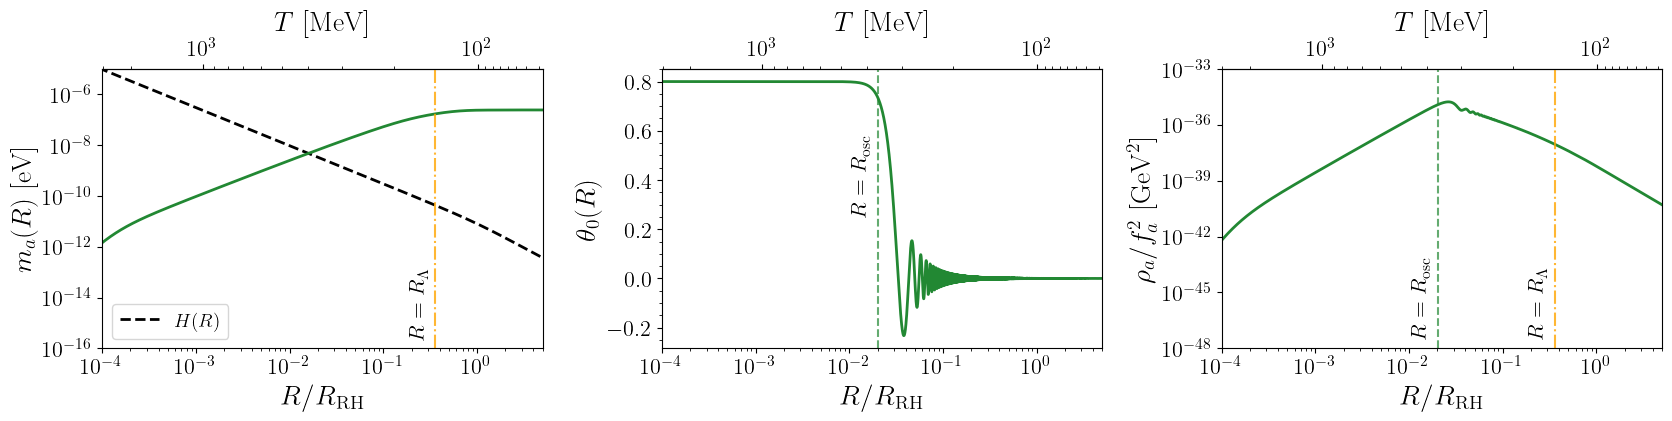

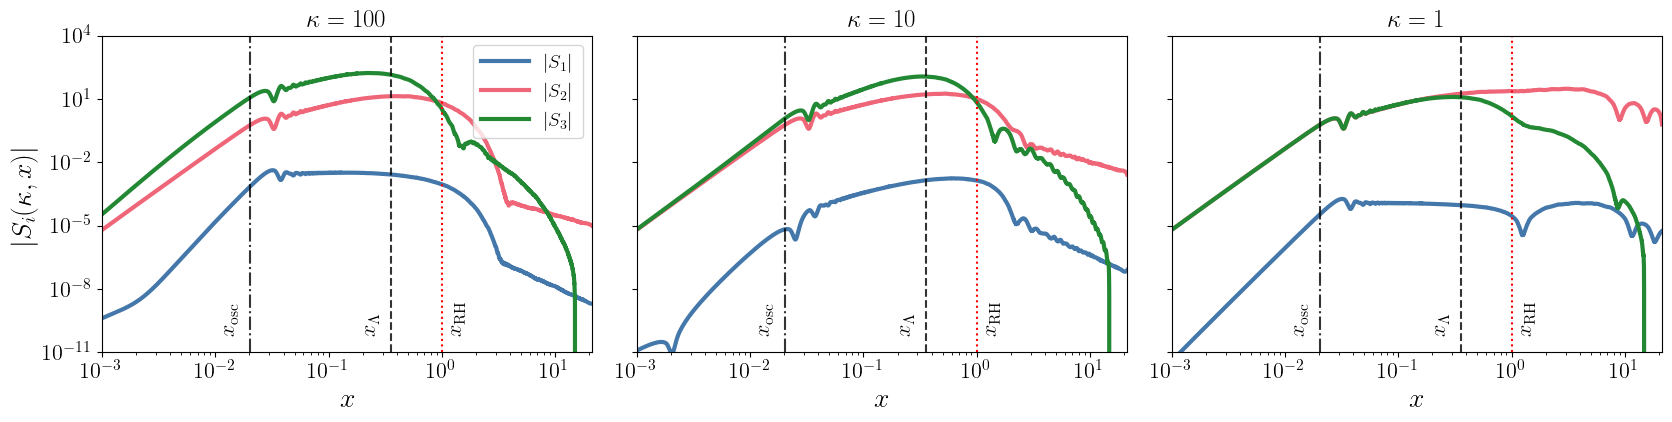

In [11]:
GeV_to_eV = 1e9
x = R / R_RH
x_min, x_max = 1e-4, 5.0
colors_b = {0: "#4477AA", 2: "#228833", 4: "#EE6677"}

x_to_T = interp1d(x, Temp * 1e3, bounds_error=False, fill_value="extrapolate")
T_to_x = interp1d(Temp * 1e3, x, bounds_error=False, fill_value="extrapolate")

fig, (ax_m, ax_th, ax_rho) = plt.subplots(1, 3, figsize=(17, 4.5))

ax_m.loglog(x, Hub * GeV_to_eV, color="k", lw=2, ls="--", label=r"$H(R)$")
ax_m.loglog(x, np.asarray(ma_arr) * GeV_to_eV, color=colors_b[2], lw=2)
ax_m.set_xlim(x_min, x_max)
ax_m.set_ylim(1e-16, 1e-5)
ax_m.set_xlabel(r"$R/R_{\mathrm{RH}}$")
ax_m.set_ylabel(r"$m_a(R)$ [eV]")
ax_m.legend(frameon=True, loc="lower left")

sec_m = ax_m.secondary_xaxis("top", functions=(x_to_T, T_to_x))
sec_m.set_xlabel(r"$T$ [MeV]", labelpad=7)

x_l = R_l / R_RH
x_osc = R_osc / R_RH

ax_m.axvline(x_l, color="orange", ls="-.", alpha=0.8)
ax_m.text(x_l * 0.85, 0.03, r"$R=R_\Lambda$", transform=ax_m.get_xaxis_transform(), rotation=90, rotation_mode="anchor", va="bottom", ha="left", color="black")

ax_th.plot(x, np.asarray(ax0), color=colors_b[2], lw=2)
ax_th.axvline(x_osc, color=colors_b[2], ls="--", alpha=0.7)
ax_th.text(x_osc * 0.85, 0.25, r"$R=R_{\mathrm{osc}}$", rotation=90, va="bottom", ha="right", color="black")
ax_th.set_xscale("log")
ax_th.set_xlim(x_min, x_max)
ax_th.set_xlabel(r"$R/R_{\mathrm{RH}}$")
ax_th.set_ylabel(r"$\theta_0(R)$")
ax_th.yaxis.set_minor_locator(AutoMinorLocator())

sec_th = ax_th.secondary_xaxis("top", functions=(x_to_T, T_to_x))
sec_th.set_xlabel(r"$T$ [MeV]", labelpad=7)

rho_min = 1e-48

ax_rho.loglog(x, rho_a / fa**2, color=colors_b[2], lw=2)
ax_rho.axvline(x_osc, color=colors_b[2], ls="--", alpha=0.7)
ax_rho.axvline(x_l, color="orange", ls="-.", alpha=0.8)
ax_rho.text(x_osc * 0.85, 3 * rho_min, r"$R=R_{\mathrm{osc}}$", rotation=90, va="bottom", ha="right", color="black")
ax_rho.text(x_l * 0.85, 3 * rho_min, r"$R=R_\Lambda$", rotation=90, va="bottom", ha="right", color="black")
ax_rho.set_xlim(x_min, x_max)
ax_rho.set_ylim(rho_min, 1e-33)
ax_rho.set_xlabel(r"$R/R_{\mathrm{RH}}$")
ax_rho.set_ylabel(r"$\rho_a/f_a^2~[\mathrm{GeV}^2]$")

sec_rho = ax_rho.secondary_xaxis("top", functions=(x_to_T, T_to_x))
sec_rho.set_xlabel(r"$T$ [MeV]", labelpad=7)

fig.tight_layout()
#fig.savefig("Background.pdf", dpi=300)
plt.show()
plt.close(fig)

def smooth_log(x_arr, y_arr, window=3000, order=3, dens=4):
    lx = np.log(x_arr)
    lx_u = np.linspace(lx[0], lx[-1], len(x_arr) * dens)
    y_u = interp1d(lx, y_arr, kind="linear", fill_value="extrapolate")(lx_u)
    if len(y_u) < window:
        window = len(y_u) // 2 * 2 + 1
    y_s = savgol_filter(y_u, window, order)
    return interp1d(lx_u, y_s, kind="cubic", fill_value="extrapolate")(lx)

dlnm2_dlnT = np.gradient(np.log(ma_arr**2), np.log(Temp))
dlnm2_dlnT[Temp <= 0.0101] = 0.0

def get_sources(kappa):
    i = np.argmin(np.abs(np.asarray(kappas) - kappa))
    phi = Phi_k[i][mask]
    dr = delta_r_k[i][mask]
    dphi = dPhi_dR_k[i][mask]

    HR = Hub * R
    Ct = np.zeros_like(R)
    ok = HR > 0.0
    Ct[ok] = np.sin(ax0[ok]) * (ma_arr[ok] / HR[ok])**2

    S1 = 4.0 * dphi * dax0
    S2 = -2.0 * phi * Ct
    S3 = -0.25 * dr * dlnm2_dlnT * Ct

    return smooth_log(R, np.abs(S1)), smooth_log(R, np.abs(S2)), smooth_log(R, np.abs(S3))

S1_k, S2_k, S3_k = [], [], []

for kappa in kappas:
    S1, S2, S3 = get_sources(kappa)
    S1_k.append(S1)
    S2_k.append(S2)
    S3_k.append(S3)

colors_S = ["#4477AA", "#EE6677", "#228833"]
idx_plot = [0, 2, 3]
x_end = interp1d(Temp, x, bounds_error=False, fill_value=np.nan)(0.0101) * 1.5

fig, axes = plt.subplots(1, len(idx_plot), figsize=(17, 4.5), sharey=True)

for j, (ax, idx) in enumerate(zip(axes, idx_plot)):
    ax.plot(x, S1_k[idx] * R_RH**2, color=colors_S[0], lw=3, label=r"$|S_1|$")
    ax.plot(x, S2_k[idx] * R_RH**2, color=colors_S[1], lw=3, label=r"$|S_2|$")
    ax.plot(x, S3_k[idx] * R_RH**2, color=colors_S[2], lw=3, label=r"$|S_3|$")

    ax.axvline(x_osc, color="black", ls="-.", alpha=0.8)
    ax.axvline(x_l, color="black", ls="--", alpha=0.8)
    ax.axvline(1.0, color="red", ls=":")

    trans = ax.get_xaxis_transform()
    ax.text(x_osc * 0.8, 0.05, r"$x_\mathrm{osc}$", transform=trans, rotation=90, va="bottom", ha="right")
    ax.text(x_l * 0.8, 0.05, r"$x_\Lambda$", transform=trans, rotation=90, va="bottom", ha="right")
    ax.text(1.1, 0.05, r"$x_{\mathrm{RH}}$", transform=trans, rotation=90, va="bottom", ha="left")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(fr"$\kappa = {kappas[idx]:g}$")
    ax.set_xlabel(labx)
    ax.set_xlim(1e-3, x_end)
    ax.set_ylim(1e-11, 1e4)

    if j == 0:
        ax.set_ylabel(r"$|S_i(\kappa,x)|$")
        ax.legend(loc="upper right", frameon=True, framealpha=0.8, handlelength=2.5)

fig.tight_layout()
fig.savefig("Plots/NSC_pert/ALP_perturbations/Field_perts/Sources_ma2.4e-7eV_100-10-1_average.pdf", dpi=300)
plt.show()
plt.close(fig)
